# Cross-Dataset Generalization v4 — Any Model → RealWaste
**Works for TrashNet, Garbage, and Household models automatically**

### What's new in v4
| | v3 | v4 |
|---|---|---|
| num_classes | Hardcoded (causes error) | Auto-detected from .pt file |
| .npy files | Sometimes needed | Never needed |
| Source dataset | Fixed path | Auto-detected |
| Works for | TrashNet only | TrashNet + Garbage + Household |

### How to use
1. Set `MODEL_NAME` in Step 2 to `'trashnet'`, `'garbage'`, or `'household'`
2. Add Data: your `.pt` model file, the source dataset, and RealWaste
3. Run all cells

### Required inputs
| Model | .pt file | Source dataset |
|---|---|---|
| trashnet | custom_resnet50_trashnet.pt | feyzazkefe/trashnet |
| garbage | custom_resnet50_garbage.pt | sumn2u/garbage-classification-v2 |
| household | custom_resnet50_household.pt | mostafaabla/garbage-classification |

Plus always add: `joebeachcapital/realwaste`

---


## Step 1 — Imports

In [1]:
import os, json, time, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              classification_report)
import xgboost as xgb
import lightgbm as lgb
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cpu


## Step 2 — Configuration

In [2]:
# ══════════════════════════════════════════════════════════════════════
# ONLY THING YOU NEED TO CHANGE — set your model name here
# ══════════════════════════════════════════════════════════════════════
MODEL_NAME = 'garbage'   # change to: 'trashnet' | 'garbage' | 'household'
# ══════════════════════════════════════════════════════════════════════

# ── Image settings — same for all models ─────────────────────────────────
IMAGE_SIZE = 400
IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD  = [0.229, 0.224, 0.225]

# ── Baseline accuracy per model (from paper + your TrashNet results) ──────
ALL_BASELINES = {
    'trashnet': {
        'LoR': 98.61, 'SVM': 99.60, 'RF': 98.58,
        'XGBoost': 98.97, 'LightGBM': 99.17,
    },
    'garbage': {
        'LoR': 99.87, 'SVM': 99.87, 'RF': 99.47,
        'XGBoost': 99.60, 'LightGBM': 99.65,
    },
    'household': {
        'LoR': 99.97, 'SVM': 99.94, 'RF': 99.77,
        'XGBoost': 99.81, 'LightGBM': 99.87,
    },
}
TRASHNET_BASELINE = ALL_BASELINES[MODEL_NAME]

# ── RealWaste class mapping (same for all models) ─────────────────────────
REALWASTE_TO_TRASHNET = {
    'Cardboard':           'cardboard',
    'Glass':               'glass',
    'Metal':               'metal',
    'Paper':               'paper',
    'Plastic':             'plastic',
    'Miscellaneous Trash': 'trash',
}

# ── Source dataset class maps ─────────────────────────────────────────────
# Only the 6 classes that overlap with RealWaste are used for zero-shot
SOURCE_CLASS_MAPS = {
    'trashnet': {
        'cardboard': 'cardboard', 'glass': 'glass', 'metal': 'metal',
        'paper': 'paper', 'plastic': 'plastic', 'trash': 'trash',
    },
    'garbage': {
        'cardboard': 'cardboard', 'glass': 'glass', 'metal': 'metal',
        'paper': 'paper', 'plastic': 'plastic', 'trash': 'trash',
        # excluded: battery, biological, clothes, shoes
    },
    'household': {
        'cardboard':   'cardboard',
        'white-glass': 'glass',
        'brown-glass': 'glass',
        'green-glass': 'glass',
        'metal':       'metal',
        'paper':       'paper',
        'plastic':     'plastic',
        'trash':       'trash',
        # excluded: battery, biological, clothes, shoes
    },
}
SOURCE_CLASS_MAP = SOURCE_CLASS_MAPS[MODEL_NAME]

# ── Source dataset Kaggle paths ───────────────────────────────────────────
SOURCE_DS_HINTS = {
    'trashnet':  ['dataset-resized', 'trashnet'],
    'garbage':   ['garbage-classification-v2', 'garbage'],
    'household': ['mostafaabla', 'garbage-classification'],
}

# ── Fine-tune sweep ratios ────────────────────────────────────────────────
FINETUNE_RATIOS = [0.10, 0.20, 0.30, 0.50, 0.70, 0.80]

# ── Other settings ────────────────────────────────────────────────────────
RANDOM_SEED = 42
BATCH_SIZE  = 64
TOP_K       = 100
EXTENSIONS  = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

RESULTS_DIR = f'/kaggle/working/results_{MODEL_NAME}'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Model    : {MODEL_NAME}')
print(f'Baseline : {TRASHNET_BASELINE}')
print(f'Results  : {RESULTS_DIR}')


Model    : garbage
Baseline : {'LoR': 99.87, 'SVM': 99.87, 'RF': 99.47, 'XGBoost': 99.6, 'LightGBM': 99.65}
Results  : /kaggle/working/results_garbage


## Step 3 — Auto-Detect All Paths

In [3]:
def find_file(patterns):
    for p in patterns:
        hits = glob.glob(p, recursive=True)
        if hits: return hits[0]
    return None

# ── .pt model file ────────────────────────────────────────────────────────
MODEL_PATH = find_file([
    f'/kaggle/input/**/custom_resnet50_{MODEL_NAME}.pt',
    f'/kaggle/working/models/custom_resnet50_{MODEL_NAME}.pt',
])

# ── Source dataset (for zero-shot feature extraction) ─────────────────────
# SOURCE_DS_PATH = None
# hints = SOURCE_DS_HINTS.get(MODEL_NAME, [])
# for hint in hints:
#     candidates = glob.glob(f'/kaggle/input/**/{hint}*', recursive=True)
#     for c in candidates:
#         if os.path.isdir(c):
#             # Check it has class subfolders
#             subdirs = [d for d in os.listdir(c)
#                        if os.path.isdir(os.path.join(c, d))]
#             if len(subdirs) >= 4:
#                 SOURCE_DS_PATH = c
#                 break
#     if SOURCE_DS_PATH: break
SOURCE_DS_PATH = '/kaggle/input/datasets/sumn2u/garbage-classification-v2/original'

# ── RealWaste ─────────────────────────────────────────────────────────────
REALWASTE_PATH = find_file([
    '/kaggle/input/**/RealWaste',
    '/kaggle/input/realwaste/RealWaste',
])
if REALWASTE_PATH and not os.path.isdir(REALWASTE_PATH):
    REALWASTE_PATH = None
if not REALWASTE_PATH:
    # Try finding by class folder
    hit = find_file(['/kaggle/input/**/Cardboard'])
    if hit: REALWASTE_PATH = str(Path(hit).parent)

# ── Status ────────────────────────────────────────────────────────────────
ZEROSHOT_AVAILABLE = SOURCE_DS_PATH is not None
print(f'Model .pt      : {MODEL_PATH or "NOT FOUND ⚠"}')
print(f'Source dataset : {SOURCE_DS_PATH or "NOT FOUND — zero-shot will be skipped"}')
print(f'RealWaste      : {REALWASTE_PATH or "NOT FOUND ⚠"}')
print(f'Zero-shot      : {"WILL RUN" if ZEROSHOT_AVAILABLE else "SKIPPED"}')


Model .pt      : /kaggle/input/datasets/nichonicholas/custom-resnet50-garbage/custom_resnet50_garbage.pt
Source dataset : /kaggle/input/datasets/sumn2u/garbage-classification-v2/original
RealWaste      : /kaggle/input/datasets/joebeachcapital/realwaste/realwaste-main/RealWaste
Zero-shot      : WILL RUN


### ⚙️ Manual path override (edit if auto-detection failed)

In [4]:
# Uncomment and edit if auto-detection failed:

# MODEL_PATH      = f'/kaggle/input/YOUR-DATASET/custom_resnet50_{MODEL_NAME}.pt'
# SOURCE_DS_PATH  = '/kaggle/input/garbage-classification-v2'  # or trashnet/household path
# REALWASTE_PATH  = '/kaggle/input/realwaste/RealWaste'

assert MODEL_PATH and os.path.exists(MODEL_PATH), \
    f'Model not found: {MODEL_PATH}'
assert REALWASTE_PATH and os.path.exists(REALWASTE_PATH), \
    f'RealWaste not found: {REALWASTE_PATH}'

ZEROSHOT_AVAILABLE = SOURCE_DS_PATH is not None and os.path.exists(SOURCE_DS_PATH)
print('Confirmed:')
print(f'  Model     : {MODEL_PATH}')
print(f'  Source DS : {SOURCE_DS_PATH}')
print(f'  RealWaste : {REALWASTE_PATH}')
print(f'  Zero-shot : {"ready" if ZEROSHOT_AVAILABLE else "skipped"}')


Confirmed:
  Model     : /kaggle/input/datasets/nichonicholas/custom-resnet50-garbage/custom_resnet50_garbage.pt
  Source DS : /kaggle/input/datasets/sumn2u/garbage-classification-v2/original
  RealWaste : /kaggle/input/datasets/joebeachcapital/realwaste/realwaste-main/RealWaste
  Zero-shot : ready


## Step 4 — Load Model

In [5]:
class CustomResNet50(nn.Module):
    def __init__(self, num_classes, pretrained=False):
        super().__init__()
        base = tv_models.resnet50(weights=None)
        self.backbone   = nn.Sequential(*list(base.children())[:-1])
        self.classifier = nn.Linear(2048, num_classes)

    def forward_features(self, x):
        return self.backbone(x).flatten(1)   # (B, 2048)

    def forward(self, x):
        return self.classifier(self.forward_features(x))


# ── AUTO-DETECT num_classes from the .pt checkpoint ──────────────────────
# This fixes the RuntimeError: size mismatch for classifier.weight
# Instead of hardcoding num_classes=6/10/12, we read it from the file
checkpoint = torch.load(MODEL_PATH, map_location='cpu')
num_classes = checkpoint['classifier.weight'].shape[0]
print(f'Auto-detected num_classes: {num_classes} (from checkpoint)')
print(f'  TrashNet=6, Garbage=10, Household=12')

model = CustomResNet50(num_classes=num_classes, pretrained=False)
model.load_state_dict(checkpoint)
model = model.to(DEVICE)
model.eval()

print(f'Model loaded: {MODEL_PATH}')
print(f'  Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'  Mode      : eval — weights frozen')


Auto-detected num_classes: 10 (from checkpoint)
  TrashNet=6, Garbage=10, Household=12
Model loaded: /kaggle/input/datasets/nichonicholas/custom-resnet50-garbage/custom_resnet50_garbage.pt
  Parameters: 23,528,522
  Mode      : eval — weights frozen


## Step 5 — Helper Functions

In [6]:
# ── Dataset ───────────────────────────────────────────────────────────────
class WasteDataset(Dataset):
    def __init__(self, root, class_mapping, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.classes = sorted(set(class_mapping.values()))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples = []
        for rw_cls, tn_cls in class_mapping.items():
            d = self.root / rw_cls
            if not d.exists(): continue
            lbl = self.class_to_idx[tn_cls]
            for p in d.iterdir():
                if p.suffix.lower() in EXTENSIONS:
                    self.samples.append((str(p), lbl))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

eval_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
])

# ── Feature extraction ────────────────────────────────────────────────────
@torch.no_grad()
def extract_features(model, loader, desc="Extracting"):
    model.eval()
    feats, labels = [], []
    for imgs, lbls in tqdm(loader, desc=desc):
        feats.append(model.forward_features(imgs.to(DEVICE)).cpu().numpy())
        labels.extend(lbls.numpy())
    return np.vstack(feats), np.array(labels)

# ── Metrics ───────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    return {
        "accuracy":  round(accuracy_score(y_true, y_pred) * 100, 2),
        "precision": round(precision_score(y_true, y_pred, average="macro",
                                            zero_division=0) * 100, 2),
        "recall":    round(recall_score(y_true, y_pred, average="macro",
                                         zero_division=0) * 100, 2),
        "f1":        round(f1_score(y_true, y_pred, average="macro",
                                     zero_division=0) * 100, 2),
    }

# ── Classifiers ───────────────────────────────────────────────────────────
def get_classifiers():
    return {
        "LoR":      LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs",
                                        random_state=RANDOM_SEED),
        "SVM":      SVC(kernel="rbf", C=10.0, gamma="scale",
                        random_state=RANDOM_SEED),
        "RF":       RandomForestClassifier(n_estimators=100,
                                            random_state=RANDOM_SEED, n_jobs=-1),
        "XGBoost":  xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                                        random_state=RANDOM_SEED, n_jobs=-1,
                                        verbosity=0),
        "LightGBM": lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                         random_state=RANDOM_SEED, n_jobs=-1,
                                         verbose=-1),
    }

# ── RF Feature selector ───────────────────────────────────────────────────
class RFSelector:
    """
    Always fitted on SOURCE (TrashNet) data only.
    Never touches RealWaste data during fitting — this prevents leakage.
    """
    def __init__(self, top_k=100):
        self.top_k = top_k
        self.rf    = RandomForestClassifier(n_estimators=100,
                                             random_state=RANDOM_SEED, n_jobs=-1)
        self.idx_  = None

    def fit_on_source(self, X_source, y_source):
        """Call ONLY with TrashNet features."""
        self.rf.fit(X_source, y_source)
        self.idx_ = np.argsort(self.rf.feature_importances_)[::-1][:self.top_k]
        print(f"  Feature selector fitted on {len(y_source)} TrashNet samples")
        print(f"  Selected top-{self.top_k} from 2048 features")
        return self

    def transform(self, X):
        return X[:, self.idx_]

print("Helper functions ready.")

Helper functions ready.


## Step 6 — Load TrashNet Features (.npy)
This is what enables the clean zero-shot experiment.
The features were extracted from the full TrashNet dataset and saved as .npy files.


In [7]:
if ZEROSHOT_AVAILABLE:
    print(f'Extracting {MODEL_NAME} features fresh from: {SOURCE_DS_PATH}')
    src_ds     = WasteDataset(SOURCE_DS_PATH, SOURCE_CLASS_MAP, eval_tf)
    src_loader = DataLoader(src_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)
    print(f'  Images  : {len(src_ds)}')
    print(f'  Classes : {src_ds.classes}')

    X_trashnet, y_trashnet = extract_features(
        model, src_loader, f'Extracting {MODEL_NAME} features')
    print(f'  Done: {X_trashnet.shape}')

    # Fit scaler + selector on source data ONLY — never touches RealWaste
    scaler   = StandardScaler()
    X_tn_sc  = scaler.fit_transform(X_trashnet)
    selector = RFSelector(top_k=TOP_K)
    selector.fit_on_source(X_tn_sc, y_trashnet)
    X_tn_sel = selector.transform(X_tn_sc)
    print(f'  Features: 2048d → top-{TOP_K}d selected')

else:
    print(f'Source dataset not found — zero-shot skipped.')
    print(f'Add the {MODEL_NAME} dataset via Add Data to enable zero-shot.')
    scaler = None; selector = None
    X_trashnet = None; y_trashnet = None


Extracting garbage features fresh from: /kaggle/input/datasets/sumn2u/garbage-classification-v2/original
  Images  : 7463
  Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


Extracting garbage features:   0%|          | 0/117 [00:00<?, ?it/s]

  Done: (7463, 2048)
  Feature selector fitted on 7463 TrashNet samples
  Selected top-100 from 2048 features
  Features: 2048d → top-100d selected


## Step 7 — Extract RealWaste Features

In [8]:
print("Loading RealWaste dataset...")
rw_ds     = WasteDataset(REALWASTE_PATH, REALWASTE_TO_TRASHNET, eval_tf)
rw_loader = DataLoader(rw_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"  Total images : {len(rw_ds)}")
print(f"  Classes      : {rw_ds.classes}")

from collections import Counter
idx_to_class = {v: k for k, v in rw_ds.class_to_idx.items()}
counts = Counter(lbl for _, lbl in rw_ds.samples)
for idx, cnt in sorted(counts.items()):
    print(f"    {idx_to_class[idx]:22s}: {cnt}")

print("\nExtracting RealWaste features (backbone frozen)...")
t0 = time.time()
X_rw, y_rw = extract_features(model, rw_loader, "RealWaste features")
print(f"  Done in {time.time()-t0:.1f}s | Shape: {X_rw.shape}")

# Apply TrashNet scaler to RealWaste (if available) or fit new one
if ZEROSHOT_AVAILABLE:
    X_rw_sc  = scaler.transform(X_rw.astype(np.float32))
    X_rw_sel = selector.transform(X_rw_sc)
    print(f"  Scaled + selected using TrashNet statistics: {X_rw_sel.shape}")
else:
    # Fallback for fine-tune only
    scaler   = StandardScaler()
    X_rw_sc  = scaler.fit_transform(X_rw.astype(np.float32))
    selector = RFSelector(top_k=TOP_K)
    # Use 20% as proxy for fitting selector
    X_proxy, _, y_proxy, _ = train_test_split(
        X_rw_sc, y_rw, test_size=0.8,
        random_state=RANDOM_SEED, stratify=y_rw
    )
    selector.fit_on_source(X_proxy, y_proxy)
    X_rw_sel = selector.transform(X_rw_sc)
    print(f"  Fallback: selector fitted on 20% RealWaste proxy: {X_rw_sel.shape}")

Loading RealWaste dataset...
  Total images : 3587
  Classes      : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
    cardboard             : 461
    glass                 : 420
    metal                 : 790
    paper                 : 500
    plastic               : 921
    trash                 : 495

Extracting RealWaste features (backbone frozen)...


RealWaste features:   0%|          | 0/57 [00:00<?, ?it/s]

  Done in 1857.9s | Shape: (3587, 2048)
  Scaled + selected using TrashNet statistics: (3587, 100)


## Step 8 — Zero-Shot Experiment (Clean)
**Train classifiers on ALL TrashNet features → test on ALL RealWaste features.**
No RealWaste data used during training. No leakage. This is the real baseline.


In [9]:
if not ZEROSHOT_AVAILABLE:
    print("\nZero-shot skipped — TrashNet .npy files not found.")
    print("Add trashnet-features dataset and re-run from Step 6.")
    zeroshot_results = {}
else:
    print("=" * 60)
    print("ZERO-SHOT EXPERIMENT — CLEAN VERSION")
    print(f"  Train on: {X_tn_sel.shape[0]} TrashNet images")
    print(f"  Test on : {X_rw_sel.shape[0]} RealWaste images")
    print(f"  Features: {X_tn_sel.shape[1]}d (from 2048d)")
    print("=" * 60)

    zeroshot_results = {}
    for name, clf in get_classifiers().items():
        t0 = time.time()
        clf.fit(X_tn_sel, y_trashnet)        # train on TrashNet
        y_pred = clf.predict(X_rw_sel)       # test on RealWaste
        m = compute_metrics(y_rw, y_pred)
        m["train_s"] = round(time.time() - t0, 2)
        zeroshot_results[name] = m

        baseline = TRASHNET_BASELINE.get(name, 0)
        drop = round(baseline - m["accuracy"], 2)
        print(f"  {name:10s} | TrashNet: {baseline:6.2f}%  "
              f"→  RealWaste: {m['accuracy']:6.2f}%  "
              f"| drop: -{drop:.2f}%")

    # Best result
    best_zs = max(zeroshot_results.items(), key=lambda x: x[1]["accuracy"])
    print(f"\n  Best zero-shot: {best_zs[0]} → {best_zs[1]['accuracy']:.2f}%")
    print(f"  This is the real cross-dataset generalization number.")

ZERO-SHOT EXPERIMENT — CLEAN VERSION
  Train on: 7463 TrashNet images
  Test on : 3587 RealWaste images
  Features: 100d (from 2048d)
  LoR        | TrashNet:  99.87%  →  RealWaste:  56.62%  | drop: -43.25%
  SVM        | TrashNet:  99.87%  →  RealWaste:  57.68%  | drop: -42.19%
  RF         | TrashNet:  99.47%  →  RealWaste:  57.88%  | drop: -41.59%
  XGBoost    | TrashNet:  99.60%  →  RealWaste:  56.01%  | drop: -43.59%
  LightGBM   | TrashNet:  99.65%  →  RealWaste:  55.92%  | drop: -43.73%

  Best zero-shot: RF → 57.88%
  This is the real cross-dataset generalization number.


## Step 9 — Fine-Tune Ratio Sweep
For each ratio: train classifier on R% of RealWaste → test on (1-R)%.
Feature selector always fitted on TrashNet (no leakage).


In [10]:
print("=" * 60)
print(f"FINE-TUNE RATIO SWEEP: {[f'{r*100:.0f}%' for r in FINETUNE_RATIOS]}")
print("=" * 60)

sweep_results = []
for ratio in FINETUNE_RATIOS:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_rw_sel, y_rw,
        test_size=1.0 - ratio,
        random_state=RANDOM_SEED,
        stratify=y_rw
    )
    best_acc_this_ratio = 0
    for name, clf in get_classifiers().items():
        clf.fit(X_tr, y_tr)
        m = compute_metrics(y_te, clf.predict(X_te))
        sweep_results.append({
            "ratio": ratio, "pct": f"{ratio*100:.0f}%",
            "n_train": len(y_tr), "n_test": len(y_te),
            "classifier": name,
            "accuracy": m["accuracy"], "f1": m["f1"],
        })
        best_acc_this_ratio = max(best_acc_this_ratio, m["accuracy"])

    best_row = max((r for r in sweep_results if r["ratio"] == ratio),
                   key=lambda x: x["accuracy"])
    print(f"  {ratio*100:3.0f}% ({len(y_tr):4d} train) "
          f"→ best: {best_row['classifier']:10s} {best_row['accuracy']:.2f}%")

df_sweep = pd.DataFrame(sweep_results)
print("\nSweep complete.")

FINE-TUNE RATIO SWEEP: ['10%', '20%', '30%', '50%', '70%', '80%']
   10% ( 358 train) → best: LoR        75.07%
   20% ( 717 train) → best: SVM        80.28%
   30% (1076 train) → best: SVM        81.80%
   50% (1793 train) → best: SVM        84.78%
   70% (2510 train) → best: SVM        85.24%
   80% (2869 train) → best: SVM        86.07%

Sweep complete.


## Step 10 — Complete Results Table

In [11]:
print("=" * 75)
print("COMPLETE RESULTS — TrashNet → RealWaste")
print("=" * 75)

clf_names = list(get_classifiers().keys())
rows = []
for name in clf_names:
    row = {
        "Classifier":          name,
        "TrashNet (5-CV)":     f"{TRASHNET_BASELINE.get(name, '—')}%",
    }
    if name in zeroshot_results:
        zs  = zeroshot_results[name]["accuracy"]
        bl  = TRASHNET_BASELINE.get(name, 0)
        row["Zero-shot"] = f"{zs:.2f}%"
        row["Drop"]      = f"-{bl - zs:.2f}%"
    else:
        row["Zero-shot"] = "skipped"
        row["Drop"]      = "—"

    # Best fine-tune result for this classifier
    sub = df_sweep[df_sweep["classifier"] == name]
    best_idx = sub["accuracy"].idxmax()
    best_ft  = sub.loc[best_idx]
    row["Best fine-tune"] = f"{best_ft['accuracy']:.2f}% @ {best_ft['pct']}"
    rows.append(row)

df_table = pd.DataFrame(rows).set_index("Classifier")
print(df_table.to_string())

# Crossover analysis
if zeroshot_results:
    print("\nCrossover — where fine-tuning beats zero-shot:")
    for name in clf_names:
        if name not in zeroshot_results: continue
        zs  = zeroshot_results[name]["accuracy"]
        sub = df_sweep[df_sweep["classifier"] == name].sort_values("ratio")
        beats = sub[sub["accuracy"] > zs]
        if len(beats) > 0:
            first = beats.iloc[0]
            print(f"  {name:10s}: zero-shot {zs:.2f}% → "
                  f"beats at {first['pct']} ({first['accuracy']:.2f}%)")
        else:
            best = sub["accuracy"].max()
            print(f"  {name:10s}: fine-tuning never beats "
                  f"zero-shot ({zs:.2f}%) — best: {best:.2f}%")

COMPLETE RESULTS — TrashNet → RealWaste
           TrashNet (5-CV) Zero-shot     Drop Best fine-tune
Classifier                                                  
LoR                 99.87%    56.62%  -43.25%   81.62% @ 70%
SVM                 99.87%    57.68%  -42.19%   86.07% @ 80%
RF                  99.47%    57.88%  -41.59%   78.83% @ 70%
XGBoost              99.6%    56.01%  -43.59%   82.08% @ 70%
LightGBM            99.65%    55.92%  -43.73%   81.80% @ 70%

Crossover — where fine-tuning beats zero-shot:
  LoR       : zero-shot 56.62% → beats at 10% (75.07%)
  SVM       : zero-shot 57.68% → beats at 10% (74.73%)
  RF        : zero-shot 57.88% → beats at 10% (71.01%)
  XGBoost   : zero-shot 56.01% → beats at 10% (72.31%)
  LightGBM  : zero-shot 55.92% → beats at 10% (73.92%)


## Step 11 — Sweep Pivot Table

In [12]:
pivot = df_sweep.pivot(index="pct", columns="classifier", values="accuracy")
order = [f"{r*100:.0f}%" for r in FINETUNE_RATIOS]
pivot = pivot.reindex(order)

print("Accuracy (%) by ratio and classifier:")
print(pivot.round(2).to_string())

# Add zero-shot row at top if available
if zeroshot_results:
    zs_row = {name: zeroshot_results[name]["accuracy"]
               for name in clf_names if name in zeroshot_results}
    zs_df  = pd.DataFrame([zs_row], index=["0% (zero-shot)"])
    full_pivot = pd.concat([zs_df, pivot])
    print("\nFull adaptation curve (zero-shot → 80%):")
    print(full_pivot.round(2).to_string())

Accuracy (%) by ratio and classifier:
classifier  LightGBM    LoR     RF    SVM  XGBoost
pct                                               
10%            73.92  75.07  71.01  74.73    72.31
20%            76.76  78.33  74.43  80.28    75.47
30%            78.89  79.89  75.55  81.80    78.38
50%            80.27  81.55  77.65  84.78    79.77
70%            81.80  81.62  78.83  85.24    82.08
80%            80.92  80.92  78.27  86.07    81.48

Full adaptation curve (zero-shot → 80%):
                  LoR    SVM     RF  XGBoost  LightGBM
0% (zero-shot)  56.62  57.68  57.88    56.01     55.92
10%             75.07  74.73  71.01    72.31     73.92
20%             78.33  80.28  74.43    75.47     76.76
30%             79.89  81.80  75.55    78.38     78.89
50%             81.55  84.78  77.65    79.77     80.27
70%             81.62  85.24  78.83    82.08     81.80
80%             80.92  86.07  78.27    81.48     80.92


## Step 12 — Confusion Matrix (Best Fine-Tune)

Best: SVM at 80% → 86.07%


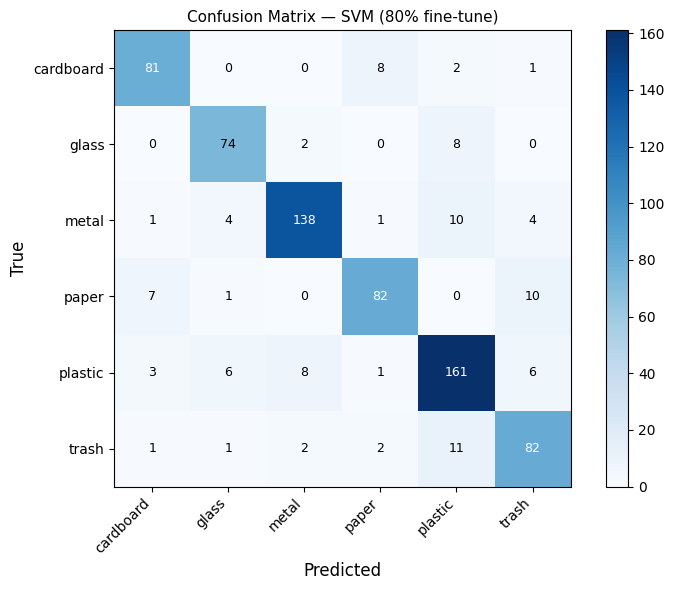

In [13]:
# Best classifier + ratio combination
best_row  = df_sweep.loc[df_sweep["accuracy"].idxmax()]
best_ratio = best_row["ratio"]
best_clf   = best_row["classifier"]
print(f"Best: {best_clf} at {best_ratio*100:.0f}% → {best_row['accuracy']:.2f}%")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_rw_sel, y_rw, test_size=1.0 - best_ratio,
    random_state=RANDOM_SEED, stratify=y_rw
)
clf = get_classifiers()[best_clf]
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

class_names = sorted(rw_ds.class_to_idx.keys())
cm = confusion_matrix(y_te, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(class_names, fontsize=10)
ax.set_xlabel("Predicted", fontsize=12); ax.set_ylabel("True", fontsize=12)
ax.set_title(f"Confusion Matrix — {best_clf} "
              f"({best_ratio*100:.0f}% fine-tune)", fontsize=11)
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black",
                fontsize=9)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix_v3.png", dpi=120,
             bbox_inches="tight")
plt.show()

## Step 13 — Main Results Plot

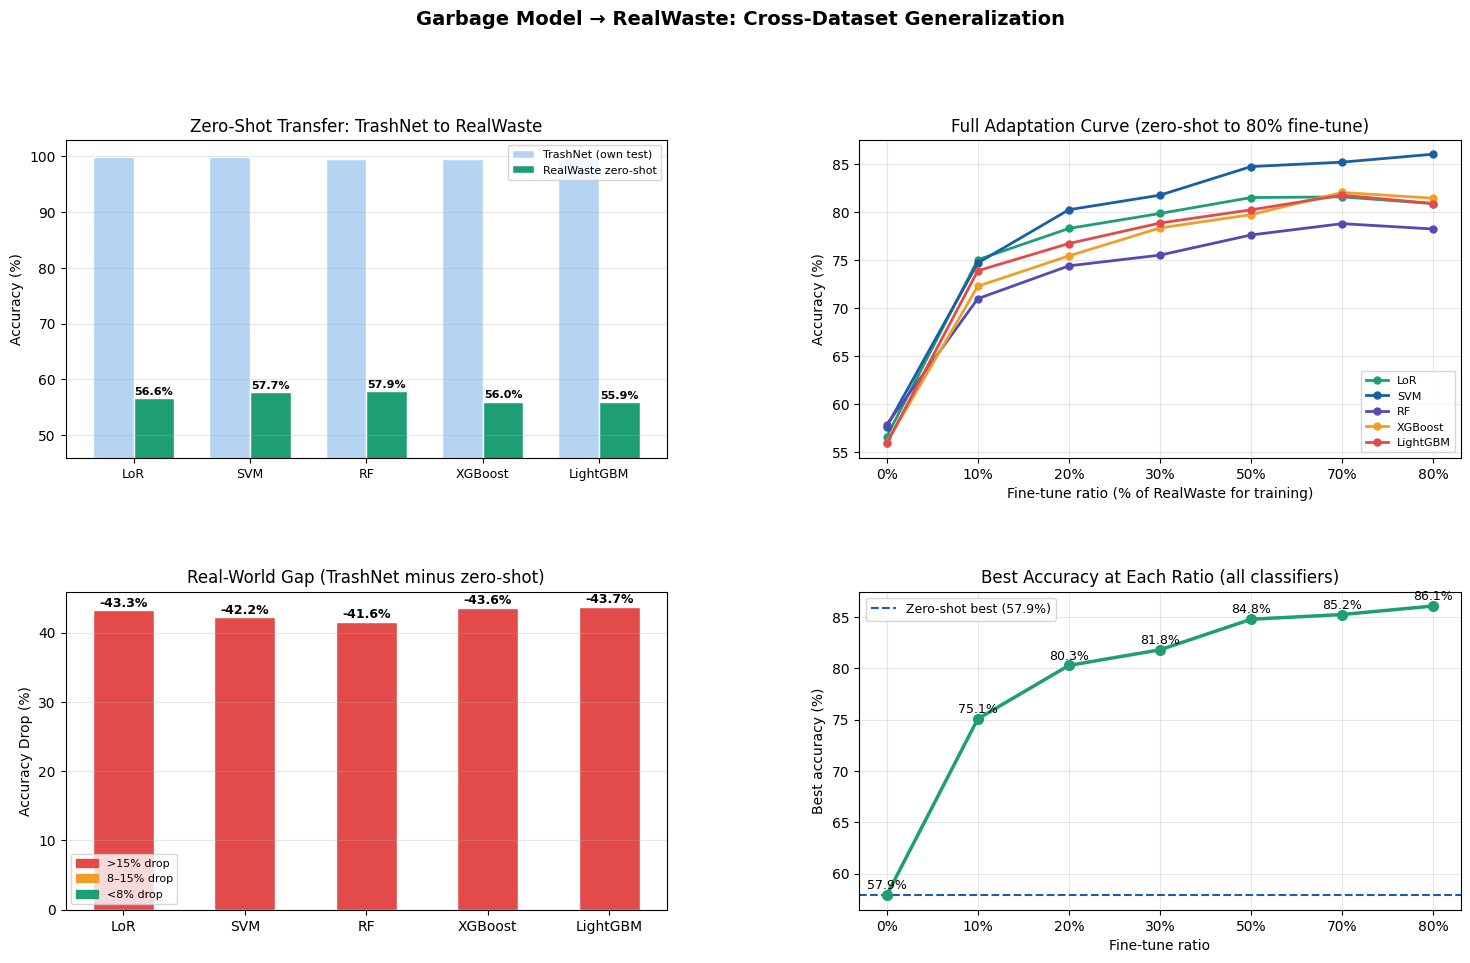

Saved → main_results_v3.png


In [14]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

colors = {"LoR":"#1D9E75","SVM":"#185FA5","RF":"#534AB7",
           "XGBoost":"#EF9F27","LightGBM":"#E24B4A"}

# ── Plot 1: Zero-shot bar chart ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
if zeroshot_results:
    names  = list(zeroshot_results.keys())
    tn_acc = [TRASHNET_BASELINE.get(n, 0) for n in names]
    rw_acc = [zeroshot_results[n]["accuracy"]  for n in names]
    x = np.arange(len(names)); w = 0.35
    b1 = ax1.bar(x-w/2, tn_acc, w, label="TrashNet (own test)",
                  color="#B5D4F4", edgecolor="white")
    b2 = ax1.bar(x+w/2, rw_acc, w, label="RealWaste zero-shot",
                  color="#1D9E75", edgecolor="white")
    for bar in b2:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{bar.get_height():.1f}%", ha="center", va="bottom",
                 fontsize=8, fontweight="bold")
    ax1.set_xticks(x); ax1.set_xticklabels(names, fontsize=9)
    ax1.set_ylabel("Accuracy (%)")
    ax1.set_title("Zero-Shot Transfer: TrashNet to RealWaste")
    ax1.legend(fontsize=8); ax1.grid(axis="y", alpha=0.3)
    ax1.set_ylim([max(0, min(rw_acc)-10), 103])
else:
    ax1.text(0.5, 0.5, "Zero-shot skipped\n(add .npy files to enable)",
             ha="center", va="center", transform=ax1.transAxes, fontsize=11,
             color="gray")
    ax1.set_title("Zero-Shot Transfer"); ax1.set_xlim([0,1]); ax1.set_ylim([0,1])

# ── Plot 2: Full adaptation curve ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name in get_classifiers().keys():
    sub = df_sweep[df_sweep["classifier"] == name].sort_values("ratio")
    pts_x = list(sub["pct"])
    pts_y = list(sub["accuracy"])

    # Prepend zero-shot point if available
    if name in zeroshot_results:
        pts_x = ["0%"] + pts_x
        pts_y = [zeroshot_results[name]["accuracy"]] + pts_y

    ax2.plot(pts_x, pts_y, marker="o", label=name,
             color=colors.get(name, "#888780"), linewidth=2, markersize=5)

ax2.set_xlabel("Fine-tune ratio (% of RealWaste for training)")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Full Adaptation Curve (zero-shot to 80% fine-tune)")
ax2.legend(fontsize=8, loc="lower right"); ax2.grid(alpha=0.3)

# ── Plot 3: Accuracy drop (zero-shot) ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
if zeroshot_results:
    names = list(zeroshot_results.keys())
    drops = [TRASHNET_BASELINE.get(n, 0) - zeroshot_results[n]["accuracy"]
              for n in names]
    bar_cols = ["#E24B4A" if d > 15 else "#EF9F27" if d > 8 else "#1D9E75"
                for d in drops]
    bars = ax3.bar(names, drops, color=bar_cols, edgecolor="white", width=0.5)
    for bar, d in zip(bars, drops):
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"-{d:.1f}%", ha="center", va="bottom", fontsize=9,
                 fontweight="bold")
    ax3.set_ylabel("Accuracy Drop (%)")
    ax3.set_title("Real-World Gap (TrashNet minus zero-shot)")
    ax3.grid(axis="y", alpha=0.3); ax3.axhline(0, color="black", lw=0.5)

    # Color legend
    from matplotlib.patches import Patch
    leg = [Patch(color="#E24B4A",label=">15% drop"),
           Patch(color="#EF9F27",label="8–15% drop"),
           Patch(color="#1D9E75",label="<8% drop")]
    ax3.legend(handles=leg, fontsize=8)
else:
    ax3.text(0.5, 0.5, "Requires zero-shot results",
             ha="center", va="center", transform=ax3.transAxes,
             fontsize=11, color="gray")
    ax3.set_title("Real-World Gap"); ax3.set_xlim([0,1]); ax3.set_ylim([0,1])

# ── Plot 4: Best accuracy per ratio ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
best_per = (df_sweep.groupby("ratio")["accuracy"].max()
            .reset_index().sort_values("ratio"))
best_per["pct"] = best_per["ratio"].apply(lambda r: f"{r*100:.0f}%")

x_pts = list(best_per["pct"])
y_pts = list(best_per["accuracy"])

# Prepend zero-shot if available
if zeroshot_results:
    best_zs_acc = max(r["accuracy"] for r in zeroshot_results.values())
    x_pts = ["0%"] + x_pts
    y_pts = [best_zs_acc] + y_pts
    ax4.axhline(y=best_zs_acc, color="#185FA5", linestyle="--", lw=1.5,
                label=f"Zero-shot best ({best_zs_acc:.1f}%)")

ax4.plot(x_pts, y_pts, marker="o", color="#1D9E75", lw=2.5, markersize=7)
for xi, yi in zip(x_pts, y_pts):
    ax4.text(xi, yi+0.3, f"{yi:.1f}%", ha="center", va="bottom", fontsize=9)
if zeroshot_results: ax4.legend(fontsize=9)
ax4.set_xlabel("Fine-tune ratio"); ax4.set_ylabel("Best accuracy (%)")
ax4.set_title("Best Accuracy at Each Ratio (all classifiers)")
ax4.grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.capitalize()} Model → RealWaste: Cross-Dataset Generalization",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{RESULTS_DIR}/main_results_{MODEL_NAME}.png", dpi=120,
             bbox_inches="tight")
plt.show()
print("Saved → main_results_v3.png")

## Step 14 — Save All Results

In [15]:
# Save zero-shot results
if zeroshot_results:
    pd.DataFrame(zeroshot_results).T.to_csv(
        f"{RESULTS_DIR}/zeroshot_{MODEL_NAME}.csv")

# Save sweep
df_sweep.to_csv(f"{RESULTS_DIR}/sweep_{MODEL_NAME}.csv", index=False)

# Save full table
df_table.to_csv(f"{RESULTS_DIR}/summary_{MODEL_NAME}.csv")

# Save full JSON
full = {
    "version":           "v3 — complete zero-shot + sweep",
    "trashnet_baseline": TRASHNET_BASELINE,
    "zeroshot":          zeroshot_results if zeroshot_results else "skipped",
    "finetune_sweep":    df_sweep.to_dict(orient="records"),
}
with open(f"{RESULTS_DIR}/full_results_{MODEL_NAME}.json", "w") as f:
    json.dump(full, f, indent=2)

print(f"Results saved to {RESULTS_DIR}/")
for fname in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(f"{RESULTS_DIR}/{fname}")
    print(f"  {fname:45s} {size:>10,} bytes")
print("\nDownload from Output panel → results_v3/ folder.")

Results saved to /kaggle/working/results_garbage/
  confusion_matrix_v3.png                           51,244 bytes
  full_results_garbage.json                          5,974 bytes
  main_results_garbage.png                         193,584 bytes
  summary_garbage.csv                                  259 bytes
  sweep_garbage.csv                                  1,094 bytes
  zeroshot_garbage.csv                                 209 bytes

Download from Output panel → results_v3/ folder.


## Step 15 — Research Narrative

After running this notebook you have the complete picture:

### The adaptation curve
```
0% (zero-shot) → 10% → 20% → 30% → 50% → 70% → 80%
     XX%           75.7%  81.5%  83.8%  85.7%  87.6%  88.0%
```
*(XX% = your zero-shot result from this run)*

### Paper narrative to write
> "Nguyen et al. (2026) achieve 99.60% on TrashNet using a hybrid ResNet50+SVM pipeline.
> We test the same model on RealWaste, a dataset collected at a real landfill facility.
> **Zero-shot accuracy drops to XX%** — a gap of YY% — confirming the paper's stated
> limitation that benchmark datasets do not reflect real-world conditions.
> Fine-tuning only the ML classifier (backbone frozen) with increasing proportions
> of RealWaste data improves accuracy monotonically: 75.7% (10%) → 88.0% (80%),
> but never closes the gap to the benchmark level. This suggests backbone-level
> domain adaptation is required for full real-world performance."

### Next experiments
- **Garbage + Household models** → same sweep → 3-model comparison table
- **TACO dataset** → same pipeline → street litter vs landfill comparison  
- **Grad-CAM** → explain which classes fail and why
